In [3]:
#!pip install --upgrade pandas
#!pip install --upgrade openpyxl
from collections import Counter
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import numpy as np
import pandas as pd
import re
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, log_loss, mean_absolute_error, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

In [139]:
df = pd.read_excel(r'C:\Users\indub\Downloads\Gmail_Extractor\Gmail_Extracted_Data_original.xlsx')

In [28]:
df.head()

,Message ID,Thread ID,Email Date Header,Action System Time,Action Type Status,From (Name),From (Email),To,CC Count,BCC,Subject,Labels,Snippet,Body Type,Has Attachments
0,19eaf27c146e1f1b,19ea84ae3d189208,10 Jun 2026 07:01:14 +0530,2026-06-10 07:01:14,Unread (No Action),IITR Spam Notification,noreply-emailsupport@iitr.ac.in,kousik_kb@ch.iitr.ac.in,0,NaN,Updates: Your List of Quarantined Emails since...,"UNREAD, IMPORTANT, CATEGORY_PERSONAL, INBOX",Spam Quarantine Notification Dear kousik_kb@ch...,HTML,No
1,19eaeb75927ecd69,19eaeb75927ecd69,"Wed, 10 Jun 2026 04:56:00 +0530",2026-06-10 04:56:00,Unread (No Action),General Secretary Hostel Affairs,gensec.hostel@iitr.ac.in,students-notices@iitr.ac.in,0,NaN,Open Projects 2026 – Build What You Want to Build,"UNREAD, IMPORTANT, CATEGORY_PERSONAL, INBOX","Greetings from Hostel Council IIT Roorkee, In ...",Plain Text,Yes
2,19eade658a6a585d,19eade658a6a585d,"Wed, 10 Jun 2026 01:08:22 +0530",2026-06-10 01:08:22,Read (Opened),National Service Scheme - NSS IIT Roorkee,nss@iitr.ac.in,students-notices@iitr.ac.in,0,NaN,NSS Open Projects 2026 | Problem Statements Ac...,"CATEGORY_PERSONAL, INBOX","Dear Students, Warm Greetings from the Nationa...",HTML,No
3,19ead70f781ac5d0,19ea84ae3d189208,09 Jun 2026 23:01:58 +0530,2026-06-09 23:01:58,Unread (No Action),IITR Spam Notification,noreply-emailsupport@iitr.ac.in,kousik_kb@ch.iitr.ac.in,0,NaN,Updates: Your List of Quarantined Emails since...,"UNREAD, IMPORTANT, CATEGORY_PERSONAL, INBOX",Spam Quarantine Notification Dear kousik_kb@ch...,HTML,No
4,19eac95b242bdbbc,19ea84ae3d189208,09 Jun 2026 19:02:28 +0530,2026-06-09 19:02:28,Read (Opened),IITR Spam Notification,noreply-emailsupport@iitr.ac.in,kousik_kb@ch.iitr.ac.in,0,NaN,Updates: Your List of Quarantined Emails since...,"IMPORTANT, CATEGORY_PERSONAL, INBOX",Spam Quarantine Notification Dear kousik_kb@ch...,HTML,No


My focus is entirely on Read and non-spam emails , so filtering out them

In [140]:
df_filtered=df[(df['Action Type Status']=='Read (Opened)') & (df['From (Name)']!='IITR Spam Notification')]

Creating Social and Thread Features

In [141]:
counts = df_filtered.groupby('From (Name)')['Snippet'].transform('count')
counts1 = df_filtered.groupby('Thread ID')['Snippet'].transform('count')
df_filtered['sender_percentage'] = counts / len(df_filtered)
df_filtered['Thread Count']=counts1
df_filtered=df_filtered[df_filtered['Labels']!='SENT']
df['Thread_count'] = 0
df.loc[df_filtered.index, 'Thread_count'] = counts1
df['sender_percentage'] = 0.0
df.loc[df_filtered.index, 'sender_percentage'] = df_filtered['sender_percentage']

In [142]:
with pd.option_context('display.max_colwidth', None):
    display(df_filtered[['Snippet']].head())

,Snippet
2,"Dear Students, Warm Greetings from the National Service Scheme (NSS), IIT Roorkee! We are delighted to announce the launch of NSS Open Projects 2026, an initiative aimed at encouraging students to"
9,"Dear Campus Community, The Institute Sports Council will organise an extended Yoga Camp from 11 June 2026 to 21 June 2026 in connection with the International Day of Yoga. Time: 6:00 AM to 7:00 AM"
10,"Dear Faculty, Staff, Scholars, and Students of IIT Roorkee, Kindly refer to the trailing email and attachment. Kindly participate in an online yoga session as part of International Day of Yoga (IDY)"
11,[ https://channeli.in/noticeboard/notice/20000 | https://channeli.in/noticeboard/notice/20000 ]
13,"Dear Students, Greetings from the Career Development Cell (CDC), IIT Roorkee! We are pleased to invite you to an insightful talk on &quot;Narrative Intelligence: Human-centred Communication for the"


Text cleaning and preprocessing

In [143]:
# Load English stopwords
stop_words = set(stopwords.words('english'))
def preprocess_email_text(text):
    # 1. Handle missing/NaN values
    if pd.isna(text) or not isinstance(text, str):
        return ""
    # 2. Lowercase the text
    text = text.lower()
    # 3. Clean email-specific noise (URLs, weird punctuation, or leftover HTML)
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'<.*?>', '', text)                 # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)           # Keep only letters and spaces
    # 4. Tokenize (break into individual words)
    words = word_tokenize(text)
    # 5. Remove stopwords and single characters (like 'u', 'x')
    filtered_words = [word for word in words if word not in stop_words and len(word) > 1]
    # 6. Join words back into a single string
    return " ".join(filtered_words)

In [144]:
df_filtered['clean_subject'] = df_filtered['Subject'].apply(preprocess_email_text)
df_filtered['clean_snippet'] = df_filtered['Snippet'].apply(preprocess_email_text)
df['clean_subject'] = df['Subject'].apply(preprocess_email_text)
df['clean_snippet'] = df['Snippet'].apply(preprocess_email_text)
df_filtered[['Subject', 'clean_subject', 'Snippet', 'clean_snippet']].head()

,Subject,clean_subject,Snippet,clean_snippet
2,NSS Open Projects 2026 | Problem Statements Ac...,nss open projects problem statements across tr...,"Dear Students, Warm Greetings from the Nationa...",dear students warm greetings national service ...
9,Yoga Camp from 11 June 2026 at LBS Ground,yoga camp june lbs ground,"Dear Campus Community, The Institute Sports Co...",dear campus community institute sports council...
10,Fwd: Guinness World Record Attempt by particip...,fwd guinness world record attempt participatin...,"Dear Faculty, Staff, Scholars, and Students of...",dear faculty staff scholars students iit roork...
11,OM: Appointment of the Chairman and Vice-Chair...,om appointment chairman vicechairman gatejam,[ https://channeli.in/noticeboard/notice/20000...,
13,Invitation to Talk on Narrative Intelligence: ...,invitation talk narrative intelligence humance...,"Dear Students, Greetings from the Career Devel...",dear students greetings career development cel...


Recent Word features Creation on the basis of the last 30 days emails using rolling window

In [145]:
df["Action System Time"] = pd.to_datetime(
    df["Action System Time"], errors="coerce"
)
df = df.sort_values("Action System Time").reset_index(
    drop=True
)
rolling_30d = df.rolling(window="30D", on="Action System Time")
df["emails_last_days"] = rolling_30d["Action System Time"].count()
recent_emails = df[df["emails_last_days"] < 30]
recent_emails

,Message ID,Thread ID,Email Date Header,Action System Time,Action Type Status,From (Name),From (Email),To,CC Count,BCC,Subject,Labels,Snippet,Body Type,Has Attachments,Thread_count,sender_percentage,clean_subject,clean_snippet,emails_last_days
0,199510cea7d4c375,199510cea7d4c375,"Tue, 16 Sep 2025 11:12:21 +0530 (IST)",2025-09-16 11:12:21,Read (Opened),Institute CentralLibrary,library@iitr.ac.in,Students-Notices <students-notices@iitr.ac.in>,2,NaN,Important Notice regarding Returning Your Libr...,"CATEGORY_PERSONAL, INBOX","Dear Students, MGCL wishes for your ongoing ex...",HTML,No,1,0.011775,important notice regarding returning library b...,dear students mgcl wishes ongoing examinations...,1.0
1,1995135593f95fff,1994ed5c3543415c,"Tue, 16 Sep 2025 06:27:51 +0000",2025-09-16 11:57:51,Read (Opened),EZexam Support,support@ezexam.in,kousik_kb@ch.iitr.ac.in,0,NaN,Exam Notification,"IMPORTANT, CATEGORY_PERSONAL, INBOX","Hello, Exam &quot;Combined Test - Alphonso&quo...",Plain Text,No,1,0.006728,exam notification,hello exam quotcombined test alphonsoquot sche...,2.0
2,199515d38877f616,199515d38877f616,"Tue, 16 Sep 2025 12:39:50 +0530 (IST)",2025-09-16 12:39:50,Unread (No Action),"Dean, International Relations, IIT Roorkee",dean.ir@iitr.ac.in,Students-Notices <students-notices@iitr.ac.in>,2,NaN,Call for Nominations: Spring 2025 Exchange Pro...,"UNREAD, CATEGORY_PERSONAL, INBOX","Dear Students, Applications for the semester e...",HTML,No,0,0.000000,call nominations spring exchange program hslu ...,dear students applications semester exchange l...,3.0
3,199515ed051b0917,199515ed051b0917,"Tue, 16 Sep 2025 12:42:49 +0530 (IST)",2025-09-16 12:42:49,Read (Opened),Ashish Yadav,ashish@ch.iitr.ac.in,CHE-505 <che-505@iitr.ac.in>,0,NaN,MTE today,"IMPORTANT, CATEGORY_PERSONAL, INBOX","Dear Students, A gentle reminder for the MTE t...",HTML,No,1,0.025231,mte today,dear students gentle reminder mte today pm lh ...,4.0
4,1995164250676cf1,1995164250676cf1,"Tue, 16 Sep 2025 12:46:36 +0530 (IST)",2025-09-16 12:46:36,Read (Opened),"Dean, International Relations, IIT Roorkee",dean.ir@iitr.ac.in,Students-Notices <students-notices@iitr.ac.in>,2,NaN,Call for Exchange Program at the University of...,"CATEGORY_PERSONAL, INBOX","Dear Students, The call for the Student Exchan...",Plain Text,Yes,1,0.013457,call exchange program university porto portugal,dear students call student exchange program un...,5.0
5,199518332eba5254,199518332eba5254,"Tue, 16 Sep 2025 13:21:01 +0530 (IST)",2025-09-16 13:21:01,Unread (No Action),"Dean, International Relations, IIT Roorkee",dean.ir@iitr.ac.in,Students-Notices <students-notices@iitr.ac.in>,2,NaN,"Call for Student Exchange Program at NTHU, Taiwan","UNREAD, CATEGORY_PERSONAL, INBOX","Dear Students, Applications for the Student Ex...",HTML,No,0,0.000000,call student exchange program nthu taiwan,dear students applications student exchange pr...,6.0
6,19951b0e395755b4,19951b0e395755b4,"Tue, 16 Sep 2025 14:11:29 +0530 (IST)",2025-09-16 14:11:29,Unread (No Action),Chairman Institute Sports Council,chairman.isc@iitr.ac.in,Students-Notices <students-notices@iitr.ac.in>...,6,NaN,"All regular sports activities, including swimm...","UNREAD, CATEGORY_PERSONAL, INBOX",Dear All It is to be informed that the Institu...,HTML,No,0,0.000000,regular sports activities including swimming r...,dear informed institute going organise sangram...,7.0
7,19951b1fa4807158,19951b1fa4807158,"Tue, 16 Sep 2025 08:43:57 +0000",2025-09-16 14:13:57,Unread (No Action),Unstop,noreply@emails.unstop.com,kousik_kb@ch.iitr.ac.in,0,NaN,Registration Successful | Treasure Hunt: Month...,"UNREAD, CATEGORY_UPDATES, INBOX",Treasure Hunt: Monthly Challenge You&#39;ve su...,HTML,No,0,0.000000,registration successful treasure hunt monthly ...,treasure hunt monthly challenge youve successf...,8.0
8,19951e05f89b091b,19951e05f89b091b,"Tue, 16 Sep 2025 09:34:40 +0000",2025-09-16 15:04:40,Unread (No Action),Saptarshi ML-Engineer@LinkedIn,no-reply@propeers.in,kousik_kb@ch.iitr.ac.i

From the distribution of the frequency of the words for each email, I have used top 95 percentile words for each email for creation of the recent feature

In [146]:
contains_top_words_list = []

for idx, current_email in df.iterrows():
    current_time = current_email["Action System Time"]
    window_start = current_time - pd.Timedelta(days=30)

    history_window = df[
        (df["Action System Time"] >= window_start)
        & (df["Action System Time"] <= current_time)
    ]

    read_history = history_window[
        ~history_window["Labels"].str.contains("UNREAD", na=False)
    ]

    window_text = " ".join(
        read_history["clean_subject"].astype(str)
        + " "
        + read_history["clean_snippet"].astype(str)
    ).lower()

    window_words = window_text.split()
    window_counts = Counter(window_words)

    if not window_counts:
        contains_top_words_list.append(0)
        continue

    word_freq_df = pd.DataFrame(
        window_counts.items(), columns=["Word", "Frequency"]
    )
    percentile_threshold = word_freq_df["Frequency"].quantile(0.95)

    top_95_words = word_freq_df[
        word_freq_df["Frequency"] >= percentile_threshold
    ]["Word"].tolist()

    current_text = (
        str(current_email["clean_subject"])
        + " "
        + str(current_email["clean_snippet"])
    ).lower()
    pattern = r"\b(" + "|".join(map(re.escape, top_95_words)) + r")\b"

    if re.search(pattern, current_text):
        contains_top_words_list.append(1)
    else:
        contains_top_words_list.append(0)

df["contains_top_words"] = contains_top_words_list

In [147]:
df

,Message ID,Thread ID,Email Date Header,Action System Time,Action Type Status,From (Name),From (Email),To,CC Count,BCC,...,Labels,Snippet,Body Type,Has Attachments,Thread_count,sender_percentage,clean_subject,clean_snippet,emails_last_days,contains_top_words
0,199510cea7d4c375,199510cea7d4c375,"Tue, 16 Sep 2025 11:12:21 +0530 (IST)",2025-09-16 11:12:21,Read (Opened),Institute CentralLibrary,library@iitr.ac.in,Students-Notices <students-notices@iitr.ac.in>,2,NaN,...,"CATEGORY_PERSONAL, INBOX","Dear Students, MGCL wishes for your ongoing ex...",HTML,No,1,0.011775,important notice regarding returning library b...,dear students mgcl wishes ongoing examinations...,1.0,1
1,1995135593f95fff,1994ed5c3543415c,"Tue, 16 Sep 2025 06:27:51 +0000",2025-09-16 11:57:51,Read (Opened),EZexam Support,support@ezexam.in,kousik_kb@ch.iitr.ac.in,0,NaN,...,"IMPORTANT, CATEGORY_PERSONAL, INBOX","Hello, Exam &quot;Combined Test - Alphonso&quo...",Plain Text,No,1,0.006728,exam notification,hello exam quotcombined test alphonsoquot sche...,2.0,1
2,199515d38877f616,199515d38877f616,"Tue, 16 Sep 2025 12:39:50 +0530 (IST)",2025-09-16 12:39:50,Unread (No Action),"Dean, International Relations, IIT Roorkee",dean.ir@iitr.ac.in,Students-Notices <students-notices@iitr.ac.in>,2,NaN,...,"UNREAD, CATEGORY_PERSONAL, INBOX","Dear Students, Applications for the semester e...",HTML,No,0,0.000000,call nominations spring exchange program hslu ...,dear students applications semester exchange l...,3.0,0
3,199515ed051b0917,199515ed051b0917,"Tue, 16 Sep 2025 12:42:49 +0530 (IST)",2025-09-16 12:42:49,Read (Opened),Ashish Yadav,ashish@ch.iitr.ac.in,CHE-505 <che-505@iitr.ac.in>,0,NaN,...,"IMPORTANT, CATEGORY_PERSONAL, INBOX","Dear Students, A gentle reminder for the MTE t...",HTML,No,1,0.025231,mte today,dear students gentle reminder mte today pm lh ...,4.0,1
4,1995164250676cf1,1995164250676cf1,"Tue, 16 Sep 2025 12:46:36 +0530 (IST)",2025-09-16 12:46:36,Read (Opened),"Dean, International Relations, IIT Roorkee",dean.ir@iitr.ac.in,Students-Notices <students-notices@iitr.ac.in>,2,NaN,...,"CATEGORY_PERSONAL, INBOX","Dear Students, The call for the Student Exchan...",Plain Text,Yes,1,0.013457,call exchange program university porto portugal,dear students call student exchange program un...,5.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,19eac95b242bdbbc,19ea84ae3d189208,09 Jun 2026 19:02:28 +0530,2026-06-09 19:02:28,Read (Opened),IITR Spam Notification,noreply-emailsupport@iitr.ac.in,kousik_kb@ch.iitr.ac.in,0,NaN,...,"IMPORTANT, CATEGORY_PERSONAL, INBOX",Spam Quarantine Notification Dear kousik_kb@ch...,HTML,No,0,0.000000,updates list quarantined emails since last not...,spam quarantine notification dear kousikkbchii...,237.0,1
2996,19ead70f781ac5d0,19ea84ae3d189208,09 Jun 2026 23:01:58 +0530,2026-06-09 23:01:58,Unread (No Action),IITR Spam Notification,noreply-emailsupport@iitr.ac.in,kousik_kb@ch.iitr.ac.in,0,NaN,...,"UNREAD, IMPORTANT, CATEGORY_PERSONAL, INBOX",Spam Quarantine Notification Dear kousik_kb@ch...,HTML,No,0,0.000000,updates list quarantined emails since last not...,spam quarantine notification dear kousikkbchii...,238.0,1
2997,19eade658a6a585d,19eade658a6a585d,"Wed, 10 Jun 2026 01:08:22 +0530",2026-06-10 01:08:22,Read (Opened),National Service Scheme - NSS IIT Roorkee,nss@iitr.ac.in,students-notices@iitr.ac.in,0,NaN,...,"CATEGORY_PERSONAL, INBOX","Dear Students, Warm Greetings from the Nationa...",HTML,No,1,0.009251,nss open projects problem statements across tr...,dear students warm greetings national service ...,239.0,1
2998,19eaeb75927ecd69,19eaeb75927ecd69,"Wed, 10 Jun 2026 04:56:00 +0530",2026-06-10 04:56:00,Unread (No Action),General Secretary Hostel Affairs,gensec.hostel@iitr.ac.in,students-notices@iitr.ac.in,0,NaN,...,"UNREAD, IMPORTANT, CATEGORY_PERSONAL, INBOX","Greetings from Hostel Council IIT Roorkee, In ...",Plain Text,Yes,0,0.000000,open projects build want build,greetings hostel council iit roorkee lin

Sample distribution of the recent words of the last emails

--- 95th Percentile Analysis (Past 30 Days) ---
Minimum frequency required to be in top 95th percentile: 8.0

Total unique words found: 837
Number of words in the top 95th percentile: 45

--- List of Top 95th Percentile Words ---
            Word  Frequency
0           dues         77
1       students         72
2           dear         56
3       approved         37
4            may         30
5        roorkee         28
6         marked         26
7           open         25
8            iit         23
9           year         21
10      academic         17
11        office         16
12     institute         16
13        sports         15
14        bhawan         14
15            th         13
16        posted         13
17        notice         12
18         email         12
19          june         12
20     greetings         12
21         event         11
22      national         11
23        status         11
24       changed         11
25     committee         10
26      remind

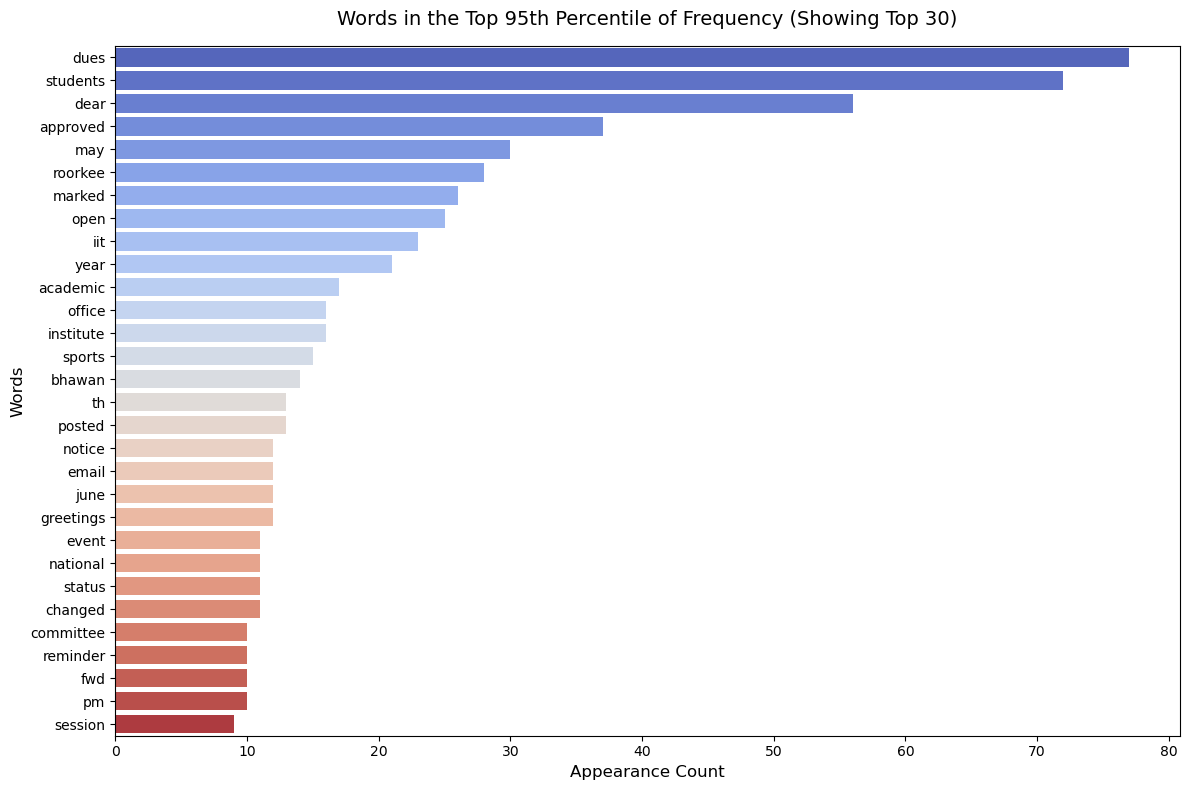

In [27]:
combined_recent_text = " ".join(
    recent_emails['clean_subject'].astype(str) + " " + recent_emails['clean_snippet'].astype(str)
)
recent_words = combined_recent_text.split()
word_counts = Counter(recent_words)
word_freq_df = pd.DataFrame(word_counts.items(), columns=['Word', 'Frequency'])
word_freq_df = word_freq_df.sort_values(by='Frequency', ascending=False).reset_index(drop=True)
percentile_threshold = word_freq_df['Frequency'].quantile(0.95)
top_95_words_df = word_freq_df[word_freq_df['Frequency'] >= percentile_threshold]
print(f"--- 95th Percentile Analysis (Past 30 Days) ---")
print(f"Minimum frequency required to be in top 95th percentile: {percentile_threshold}\n")
print(f"Total unique words found: {len(word_freq_df)}")
print(f"Number of words in the top 95th percentile: {len(top_95_words_df)}\n")
print("--- List of Top 95th Percentile Words ---")
print(top_95_words_df.to_string()) # Displays the full list
# 6. Plot the results
# Note: If there are too many words at or above the threshold, we limit the plot to the 
# top 30 most frequent ones so the chart remains clean and readable.
plot_limit = min(30, len(top_95_words_df))
words_to_plot = top_95_words_df.head(plot_limit)
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(x='Frequency', y='Word', data=words_to_plot, palette='coolwarm', ax=ax)
ax.set_title(f'Words in the Top 95th Percentile of Frequency (Showing Top {plot_limit})', fontsize=14, pad=15)
ax.set_xlabel('Appearance Count', fontsize=12)
ax.set_ylabel('Words', fontsize=12)
plt.tight_layout()
plt.show()

Content based features creation on the basis of the subject and snippet

In [148]:
combined_text = df['clean_subject'].astype(str) + " " + df['clean_snippet'].astype(str)
tfidf_vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
tfidf_matrix = tfidf_vectorizer.fit_transform(combined_text)
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(), 
    columns=tfidf_vectorizer.get_feature_names_out(),
    index=df.index
)
print(f"TF-IDF Feature Matrix Shape: {tfidf_df.shape}")
tfidf_df.head()

TF-IDF Feature Matrix Shape: (3000, 500)


,academic,academic affairs,academic year,account,administrator,administrator suspected,affairs,affairs office,agent,ai,...,want,want receive,weekly,welcome,well,work,workshop,world,year,youre
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Using PCA on the tf-idf features

In [149]:
max_components = min(500, tfidf_matrix.shape[1] - 1)
svd_initial = TruncatedSVD(n_components=max_components, random_state=42)
svd_initial.fit(tfidf_matrix)
cumulative_variance = np.cumsum(svd_initial.explained_variance_ratio_)
num_components_kept = np.argmax(cumulative_variance >= 0.90) + 1
print(f"--- Variance Analysis ---")
print(f"To explain 90% variance, you need exactly: {num_components_kept} components")

--- Variance Analysis ---
To explain 90% variance, you need exactly: 214 components


In [150]:
svd_final = TruncatedSVD(n_components=num_components_kept, random_state=42)
X_svd = svd_final.fit_transform(tfidf_matrix)
component_names = [f"tf_idf_concept_{i+1}" for i in range(X_svd.shape[1])]
tfidf_features_df = pd.DataFrame(X_svd, columns=component_names, index=df.index)
yes_no_map = {'Yes': 1, 'No': 0, 'yes': 1, 'no': 0}
structural_features = pd.DataFrame({
    'contain_top_word': df['contains_top_words'],
    'sender_percentage': df['sender_percentage'],
    'thread_count': df['Thread_count'],
'CC_count':df['CC Count'],
    'has_attachment': df['Has Attachments'].map(yes_no_map).fillna(0).astype(int)
})
X_reduced = pd.concat([structural_features, tfidf_features_df], axis=1)
print("--- Final Dataset Blueprint ---")
print(f"Total Rows (Emails): {X_reduced.shape[0]}")
print(f"Total Columns (Features): {X_reduced.shape[1]}")
print(f"Breakdown: 5 Meta Features + {X_svd.shape[1]} TF-IDF Concept Features\n")
X_reduced[['contain_top_word', 'sender_percentage', 'thread_count', 'tf_idf_concept_1', 'tf_idf_concept_2']].head()

--- Final Dataset Blueprint ---
Total Rows (Emails): 3000
Total Columns (Features): 219
Breakdown: 5 Meta Features + 214 TF-IDF Concept Features



,contain_top_word,sender_percentage,thread_count,tf_idf_concept_1,tf_idf_concept_2
0,1,0.011775,1,0.008809,0.137670
1,1,0.006728,1,0.066227,0.123528
2,0,0.000000,0,0.008869,0.171078
3,1,0.025231,1,0.010991,0.246137
4,1,0.013457,1,0.010092,0.300699


In [151]:
X_reduced=X_reduced.fillna(0)

Model Training and evaluation

In [152]:
X = X_reduced.copy()
y = (~df["Labels"].str.contains("UNREAD", na=False)).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 1. Scale data specifically for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Train Random Forest Model (on unscaled data)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
p_rf = rf_model.predict_proba(X_test)[:, 1]

# 3. Train Logistic Regression Baseline (on scaled data)
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
p_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# 4. Define Conditions based on Test Set Metadata
is_important_test = df.loc[X_test.index, "Labels"].str.contains(
    "IMPORTANT", na=False
)
is_unread_test = df.loc[X_test.index, "Labels"].str.contains("UNREAD", na=False)

conditions = [
    (is_unread_test),
    (~is_unread_test & is_important_test),
    (~is_unread_test & ~is_important_test),
]

# 5. Calculate Custom System Scores
choices_rf = [0, p_rf, np.where(p_rf > 0.5, 1 - p_rf, p_rf)]
rf_scores = np.select(conditions, choices_rf, default=0.0)

choices_lr = [0, p_lr, np.where(p_lr > 0.5, 1 - p_lr, p_lr)]
lr_scores = np.select(conditions, choices_lr, default=0.0)

results_df = pd.DataFrame(
    {
        "True_Labels": df.loc[X_test.index, "Labels"],
        "RF_Prob_(p)": p_rf,
        "RF_Optimized_Score": rf_scores,
        "LR_Baseline_Prob_(p)": p_lr,
        "LR_Baseline_Optimized_Score": lr_scores,
    },
    index=X_test.index,
)

# 6. Evaluation Tier 1: Metrics
auc_rf = roc_auc_score(y_test, p_rf)
loss_rf = log_loss(y_test, p_rf)
y_pred_binary_rf = (p_rf >= 0.5).astype(int)

auc_lr = roc_auc_score(y_test, p_lr)
loss_lr = log_loss(y_test, p_lr)
y_pred_binary_lr = (p_lr >= 0.5).astype(int)

print("=========================================")
print("       TIER 1: CLASSIFIER METRICS        ")
print("=========================================")
print(f"Random Forest ROC-AUC Score:      {auc_rf:.4f}")
print(f"Random Forest Log Loss:           {loss_rf:.4f}\n")
print(f"Logistic Regression ROC-AUC Score: {auc_lr:.4f} (With Scaling)")
print(f"Logistic Regression Log Loss:      {loss_lr:.4f}\n")

print("--- Random Forest Classification Report ---")
print(
    classification_report(
        y_test, y_pred_binary_rf, target_names=["Unread", "Read"]
    )
)

print("--- Logistic Regression Classification Report ---")
print(
    classification_report(
        y_test, y_pred_binary_lr, target_names=["Unread", "Read"]
    )
)

# 7. Evaluation Tier 2: Score Breakdown
eval_df = pd.DataFrame(
    {
        "Is_Unread": is_unread_test,
        "Is_Important": is_important_test,
        "RF_Priority_Score": rf_scores,
        "LR_Priority_Score": lr_scores,
    }
)


def get_email_state(row):
    if row["Is_Unread"]:
        return "Unread (Target = 0)"
    elif row["Is_Important"]:
        return "Read & Important (Target = p)"
    else:
        return "Read & Unimportant (Target = bounded)"


eval_df["Email_State"] = eval_df.apply(get_email_state, axis=1)

print("=========================================")
print("     TIER 2: SYSTEM CUSTOM STATS        ")
print("=========================================")

print("\n[Random Forest Priority Score Stats]")
summary_stats_rf = eval_df.groupby("Email_State")["RF_Priority_Score"].agg(
    ["count", "mean", "std", "min", "max"]
)
print(summary_stats_rf)

print("\n[Logistic Regression Priority Score Stats]")
summary_stats_lr = eval_df.groupby("Email_State")["LR_Priority_Score"].agg(
    ["count", "mean", "std", "min", "max"]
)
print(summary_stats_lr)

       TIER 1: CLASSIFIER METRICS        
Random Forest ROC-AUC Score:      0.9922
Random Forest Log Loss:           0.1908

Logistic Regression ROC-AUC Score: 0.9892 (With Scaling)
Logistic Regression Log Loss:      0.1198

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

      Unread       0.99      0.94      0.96       307
        Read       0.94      0.99      0.96       293

    accuracy                           0.96       600
   macro avg       0.96      0.96      0.96       600
weighted avg       0.96      0.96      0.96       600

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

      Unread       0.99      0.93      0.96       307
        Read       0.93      0.99      0.96       293

    accuracy                           0.96       600
   macro avg       0.96      0.96      0.96       600
weighted avg       0.96      0.96      0.96       600

     TIER 2: SYSTEM CUSTOM 

Model Interpretation

In [153]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
y_pred_prob = lr_model.predict_proba(X_train_scaled)[:, 1]

# Calculate the variance-covariance matrix of the coefficients
V = np.diag(y_pred_prob * (1 - y_pred_prob))
X_design = np.hstack([np.ones((X_train_scaled_df.shape[0], 1)), X_train_scaled_df.values])
V_inv_xt = np.dot(V, X_design)
cov_matrix = np.linalg.inv(np.dot(X_design.T, V_inv_xt))

# Extract standard errors (excluding the intercept at index 0)
standard_errors = np.sqrt(np.diag(cov_matrix))[1:]

# Calculate z-scores and p-values
coefficients = lr_model.coef_[0]
z_scores = coefficients / standard_errors
p_values = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))

# 2. Build the main feature stats dataframe
coef_df = pd.DataFrame({
    "Feature": list(X.columns),
    "Coefficient": coefficients,
    "P-Value": p_values,
    "Odds_Ratio": np.exp(coefficients),
    "Abs_Impact": np.abs(coefficients)
})

# 3. Tag TF-IDF vs Non-TF-IDF features
coef_df["Is_TFIDF"] = coef_df["Feature"].str.contains("tf_idf|__", case=False, na=False)

# 4. Isolate top 5 TF-IDF features by impact
tfidf_top5 = (
    coef_df[coef_df["Is_TFIDF"] == True]
    .sort_values(by="Abs_Impact", ascending=False)
    .head(5)
)

# 5. Isolate all non-TF-IDF features
non_tfidf_features = (
    coef_df[coef_df["Is_TFIDF"] == False]
    .sort_values(by="Abs_Impact", ascending=False)
)

# 6. Combine them together into the final requested report
final_report = pd.concat([tfidf_top5, non_tfidf_features], axis=0).reset_index(drop=True)

# 7. Print the final results
print("================================================================")
print("     INTERPRETABILITY REPORT: TOP 5 TF-IDF & NON-TF-IDF         ")
print("================================================================")
print(final_report[["Feature", "Coefficient", "P-Value", "Odds_Ratio", "Is_TFIDF"]].to_string())

     INTERPRETABILITY REPORT: TOP 5 TF-IDF & NON-TF-IDF         
             Feature  Coefficient   P-Value   Odds_Ratio  Is_TFIDF
0   tf_idf_concept_1     1.281183  0.018215     3.600895      True
1   tf_idf_concept_2    -0.688826  0.370384     0.502165      True
2  tf_idf_concept_38    -0.458363  0.166187     0.632318      True
3  tf_idf_concept_11     0.404364  0.254404     1.498349      True
4  tf_idf_concept_26     0.320018  0.285803     1.377152      True
5       thread_count     7.192922  0.000000  1329.983674     False
6  sender_percentage     2.270375  0.138190     9.683027     False
7     has_attachment    -0.130431  0.713942     0.877717     False
8           CC_count    -0.084414  0.797413     0.919051     False
9   contain_top_word    -0.039831  0.897445     0.960952     False


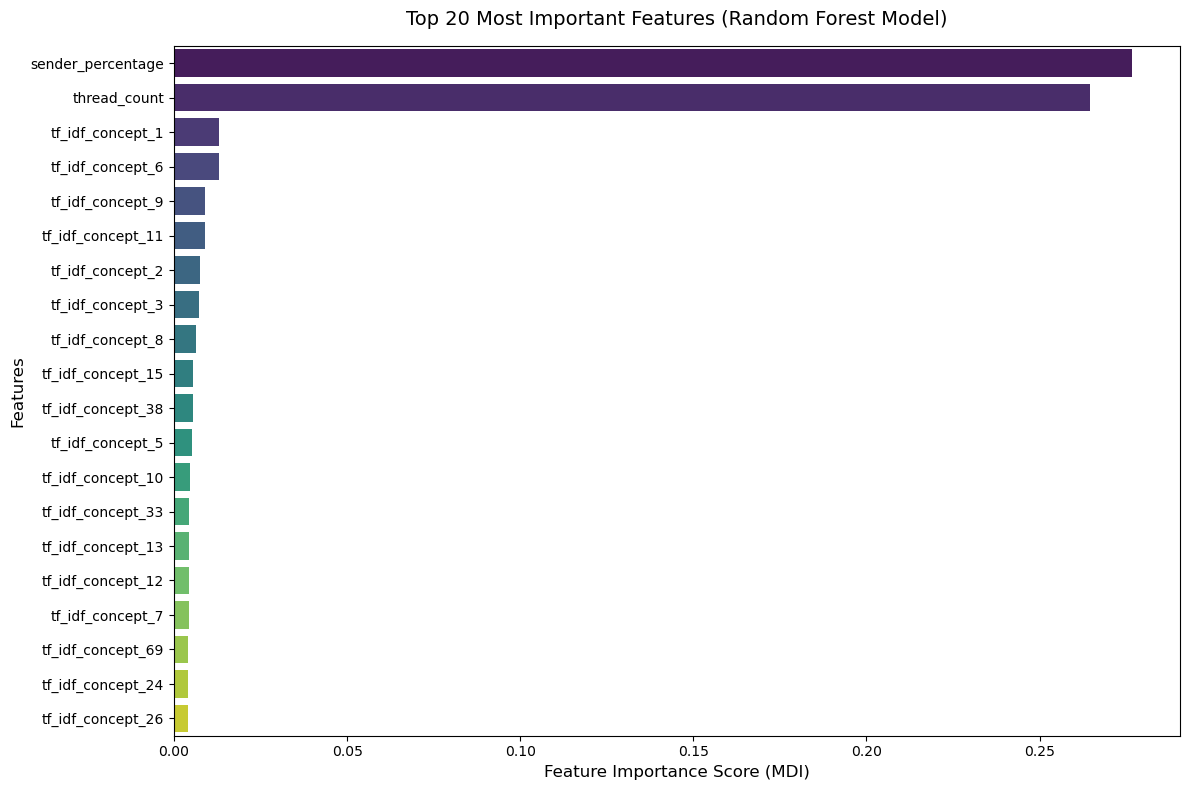

In [154]:

# 1. Create a clean dataframe for Random Forest importances
rf_importance_df = pd.DataFrame(
    {"Feature": list(X.columns), "Importance": rf_model.feature_importances_}
)

# 2. Sort by importance and select the top 20 features
rf_importance_df = rf_importance_df.sort_values(
    by="Importance", ascending=False
).head(20)

# 3. Plot the results
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(
    x="Importance",
    y="Feature",
    data=rf_importance_df,
    palette="viridis",
    ax=ax,
)

ax.set_title(
    "Top 20 Most Important Features (Random Forest Model)",
    fontsize=14,
    pad=15,
)
ax.set_xlabel("Feature Importance Score (MDI)", fontsize=12)
ax.set_ylabel("Features", fontsize=12)

plt.tight_layout()
plt.show()


Model Saving

In [155]:
import joblib
artifacts_to_save = {
    'tfidf_vectorizer': tfidf_vectorizer,  
    'svd_transformer': svd_final,         
    'model': rf_model
}
joblib.dump(artifacts_to_save, 'email_triage_artifacts.joblib')
print("🎉 Success! Your vectorizers, SVD transformers,  and ML model are safely stored in 'email_triage_artifacts.joblib'")

🎉 Success! Your vectorizers, SVD transformers,  and ML model are safely stored in 'email_triage_artifacts.joblib'
